**SECTION 1 — IMPORTS**

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

**SECTION 2 — DATASET GENERATION**

In [84]:
TICKET_TEMPLATES = {
    "Critical": [
        "Production server is down. All users affected.",
        "Database corrupted. Data loss risk.",
        "Security breach detected. Unauthorized access.",
        "Payment system failed. Transactions blocked."
    ],
    "High": [
        "VPN not working for many employees.",
        "Email server slow for all users.",
        "CRM system not syncing data.",
        "Backup failed for last 24 hours."
    ],
    "Medium": [
        "Printer not working.",
        "Software update failed.",
        "Monitor flickering.",
        "Excel crashing on large files."
    ],
    "Low": [
        "Reset my password.",
        "Need access to folder.",
        "Update email signature.",
        "Request for new mouse."
    ]
}

PRIORITY_MAP = {"Critical": 0, "High": 1, "Medium": 2, "Low": 3}
IDX_TO_PRIORITY = {v: k for k, v in PRIORITY_MAP.items()}
DEPARTMENTS = ["IT", "HR", "Finance", "Sales", "Operations"]

def generate_dataset(n=1200, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    records = []
    priorities = list(TICKET_TEMPLATES.keys())
    per_class = n // len(priorities)

    for priority in priorities:
        templates = TICKET_TEMPLATES[priority]

        for _ in range(per_class):
            base_text = random.choice(templates)
            variations = ["", " urgent issue", " please resolve asap", " system is blocked", " impacting business", " need immediate fix"]
            text = base_text + random.choice(variations)

            records.append({
                "ticket_text": text,
                "department": random.choice(DEPARTMENTS),
                "true_priority": priority,
                "true_priority_idx": PRIORITY_MAP[priority]
            })

    df = pd.DataFrame(records).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df

df = generate_dataset()
print("Dataset created:", len(df))
print(df.head())

Dataset created: 1200
                                         ticket_text  department  \
0                             Need access to folder.  Operations   
1  Excel crashing on large files. please resolve ...          IT   
2  Security breach detected. Unauthorized access....     Finance   
3  VPN not working for many employees. impacting ...  Operations   
4  Payment system failed. Transactions blocked. u...  Operations   

  true_priority  true_priority_idx  
0           Low                  3  
1        Medium                  2  
2      Critical                  0  
3          High                  1  
4      Critical                  0  


**SECTION 3 — FEATURE ENGINEERING**

In [85]:
DEPT_MAP = {d: i for i, d in enumerate(DEPARTMENTS)}

def extract_features(text, dept):
    text = text.lower()

    features = [
        int("down" in text or "crash" in text or "failed" in text),
        int("all users" in text or "entire" in text or "everyone" in text),
        int("breach" in text or "hack" in text or "unauthorized" in text),
        int("data" in text or "database" in text or "loss" in text),
        int("payment" in text or "revenue" in text or "transaction" in text),
        int("slow" in text or "delay" in text or "latency" in text),
        int("vpn" in text or "network" in text or "connectivity" in text),
        int("urgent" in text or "asap" in text or "immediately" in text),
        int("error" in text or "failure" in text),
        int("login" in text or "authentication" in text),
        int("blocked" in text or "cannot" in text),
        int("impact" in text or "business" in text),
        int("issue" in text or "problem" in text),
        int("request" in text or "please" in text or "can you" in text),
    ]

    dept_vector = [0] * len(DEPARTMENTS)
    dept_vector[DEPT_MAP[dept]] = 1

    return np.array(features + dept_vector, dtype=np.float32)

df['feature_vector'] = df.apply(lambda row: extract_features(row['ticket_text'], row['department']), axis=1)
df['state'] = df['feature_vector'].apply(lambda fv: tuple(fv.astype(int)))

print(df[['ticket_text', 'department', 'state']].head())

                                         ticket_text  department  \
0                             Need access to folder.  Operations   
1  Excel crashing on large files. please resolve ...          IT   
2  Security breach detected. Unauthorized access....     Finance   
3  VPN not working for many employees. impacting ...  Operations   
4  Payment system failed. Transactions blocked. u...  Operations   

                                               state  
0  (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
1  (1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, ...  
2  (0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, ...  
3  (0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, ...  
4  (1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, ...  


**SECTION 4 — RL CONFIGURATION**

In [86]:
N_ACTIONS = 4
ALPHA = 0.2
GAMMA = 0.9
EPSILON = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.995

**SECTION 5 — REWARD FUNCTION**

In [87]:
def compute_reward(pred, true, dept):
    diff = abs(pred - true)

    if diff == 0:
        reward = 25
    elif diff == 1:
        reward = 10
    elif diff == 2:
        reward = -5
    else:
        reward = -20

    if dept == "Finance" and pred != true:
        reward -= 10

    return reward

**SECTION 6 — Q-LEARNING AGENT**

In [88]:
class QAgent:
    def __init__(self):
        self.q = {}
        self.epsilon = EPSILON

    def get_q(self, state):
        if state not in self.q:
            self.q[state] = np.zeros(N_ACTIONS)
        return self.q[state]

    def act(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, N_ACTIONS - 1)
        return np.argmax(self.get_q(state))

    def update(self, state, action, reward, next_state):
        q_values = self.get_q(state)
        next_q_values = self.get_q(next_state)

        q_values[action] += ALPHA * (
            reward + GAMMA * np.max(next_q_values) - q_values[action]
        )

    def decay(self):
        self.epsilon = max(EPSILON_MIN, self.epsilon * EPSILON_DECAY)

agent = QAgent()

**SECTION 7 — TRAINING**

In [89]:
rewards = []
accuracies = []

n_episodes = 2000

for ep in range(n_episodes):
    total_reward = 0
    correct = 0

    batch = df.sample(n=80)

    for _, row in batch.iterrows():
        state = row['state']
        true_label = row['true_priority_idx']
        dept = row['department']

        action = agent.act(state)
        reward = compute_reward(action, true_label, dept)

        next_state = df.sample(1).iloc[0]['state']

        agent.update(state, action, reward, next_state)

        total_reward += reward
        if action == true_label:
            correct += 1

    agent.decay()

    avg_reward = total_reward / len(batch)
    accuracy = (correct / len(batch)) * 100

    rewards.append(avg_reward)
    accuracies.append(accuracy)

    if (ep + 1) % 200 == 0:
        print(f"Episode {ep+1}/{n_episodes} | Accuracy: {accuracy:.2f}%")

print("Training Complete")

Episode 200/2000 | Accuracy: 60.00%
Episode 400/2000 | Accuracy: 65.00%
Episode 600/2000 | Accuracy: 72.50%
Episode 800/2000 | Accuracy: 73.75%
Episode 1000/2000 | Accuracy: 73.75%
Episode 1200/2000 | Accuracy: 71.25%
Episode 1400/2000 | Accuracy: 67.50%
Episode 1600/2000 | Accuracy: 66.25%
Episode 1800/2000 | Accuracy: 70.00%
Episode 2000/2000 | Accuracy: 62.50%
Training Complete


**SECTION 8 — EVALUATION**

In [90]:
correct = 0

for _, row in df.iterrows():
    state = row['state']
    pred = np.argmax(agent.get_q(state))

    if pred == row['true_priority_idx']:
        correct += 1

rl_acc = correct / len(df) * 100
print("Final Accuracy:", rl_acc)

Final Accuracy: 72.58333333333333


**SECTION 9 — BASELINE COMPARISON**

In [91]:
rand_acc = sum(random.randint(0,3)==r['true_priority_idx'] for _,r in df.iterrows())/len(df)*100

rule_acc = 0
for _, r in df.iterrows():
    t = r['ticket_text'].lower()
    if "down" in t:
        p = 0
    elif "slow" in t:
        p = 1
    elif "update" in t:
        p = 2
    else:
        p = 3

    if p == r['true_priority_idx']:
        rule_acc += 1

rule_acc = rule_acc / len(df) * 100

print("Random:", rand_acc)
print("Rule:", rule_acc)
print("RL:", rl_acc)

Random: 24.5
Rule: 37.583333333333336
RL: 72.58333333333333


**SECTION 10 — VISUALIZATION**

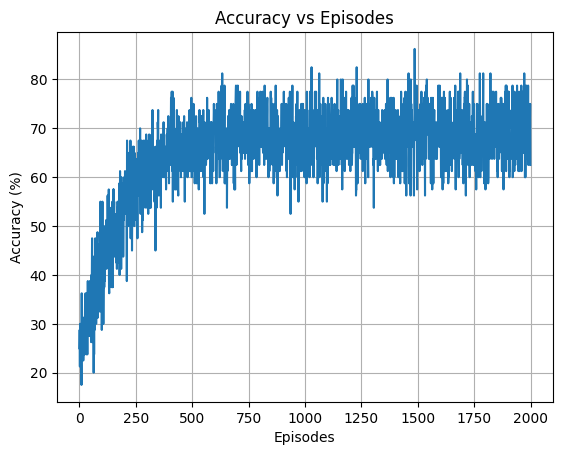

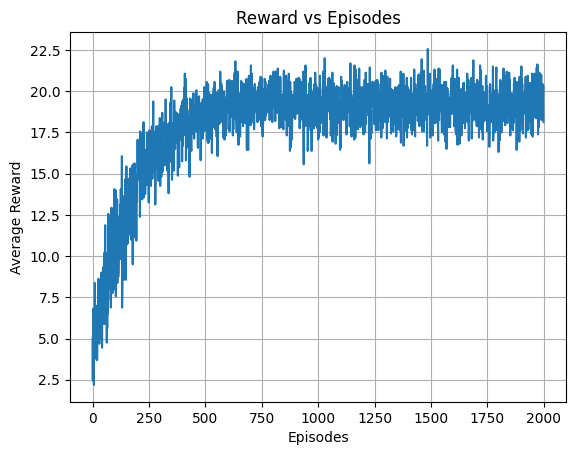

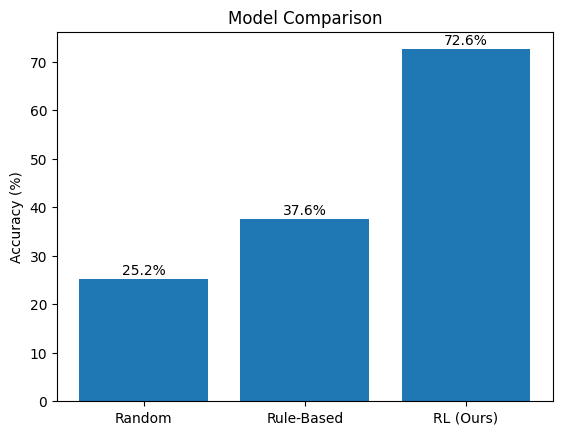

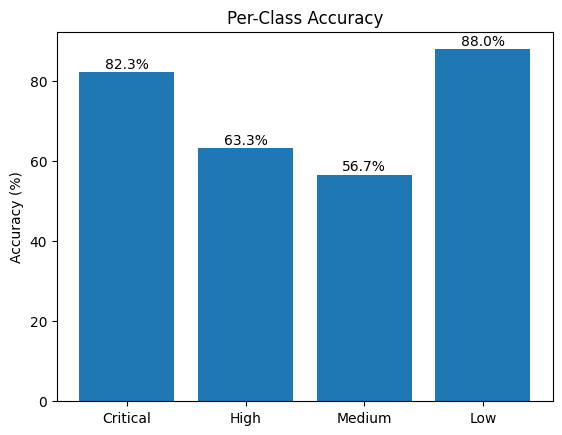


All graphs generated successfully!


In [96]:
# Graph 1 — Accuracy vs Episodes

plt.figure()
plt.plot(accuracies)
plt.title("Accuracy vs Episodes")
plt.xlabel("Episodes")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

# Graph 2 — Reward vs Episodes

plt.figure()
plt.plot(rewards)
plt.title("Reward vs Episodes")
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()


# Graph 3 — Method Comparison

# Random baseline
rand_correct = 0
for _, row in df.iterrows():
    pred = random.randint(0, 3)
    if pred == row['true_priority_idx']:
        rand_correct += 1
rand_acc = rand_correct / len(df) * 100

# Rule-based baseline
rule_correct = 0
for _, row in df.iterrows():
    text = row['ticket_text'].lower()

    if "down" in text:
        pred = 0
    elif "slow" in text:
        pred = 1
    elif "update" in text:
        pred = 2
    else:
        pred = 3

    if pred == row['true_priority_idx']:
        rule_correct += 1

rule_acc = rule_correct / len(df) * 100

# RL accuracy
methods = ["Random", "Rule-Based", "RL (Ours)"]
values = [rand_acc, rule_acc, rl_acc]

plt.figure()
plt.bar(methods, values)

plt.title("Model Comparison")
plt.ylabel("Accuracy (%)")

# Add labels
for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.show()


# Graph 5 — Per-Class Accuracy

classes = ["Critical", "High", "Medium", "Low"]
class_acc = []

for c in classes:
    sub = df[df['true_priority'] == c]
    correct = 0

    for _, row in sub.iterrows():
        pred = np.argmax(agent.get_q(row['state']))
        if pred == row['true_priority_idx']:
            correct += 1

    acc = correct / len(sub) * 100
    class_acc.append(acc)

plt.figure()
plt.bar(classes, class_acc)

plt.title("Per-Class Accuracy")
plt.ylabel("Accuracy (%)")

for i, v in enumerate(class_acc):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.show()

print("\nAll graphs generated successfully!")

**SECTION 11 — Q-TABLE**

In [97]:
print("\n--- Q-TABLE ---\n")

count = 0
for state, q_values in agent.q.items():
    print(f"State: {state}")
    print(f"Q-values: {q_values}")
    print("-"*50)

    count += 1
    if count >= 10:
        break


--- Q-TABLE ---

State: (np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0))
Q-values: [153.62042959 178.83485277 189.57809811 195.9723533 ]
--------------------------------------------------
State: (np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0))
Q-values: [180.81141147 196.81000115 164.80464972 162.74874769]
--------------------------------------------------
State: (np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), 

**SECTION 12 — POLICY**

In [98]:
print("\nLearned Policy:\n")

count = 0
for state, q_values in agent.q.items():
    best_action = np.argmax(q_values)
    print(f"State: {state} → {IDX_TO_PRIORITY[best_action]}")

    count += 1
    if count >= 10:
        break


Learned Policy:

State: (np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0)) → Low
State: (np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0)) → High
State: (np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0)) → Medium
State: (np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.in

**SECTION 13 — PREDICTION FUNCTION**

In [99]:
def predict(text, dept):
    fv = extract_features(text, dept)
    state = tuple(fv.astype(int))
    q_values = agent.get_q(state)
    return IDX_TO_PRIORITY[np.argmax(q_values)]

print("Q-values:", q_values)

Q-values: [206.33882167 165.09629901 160.6095704  101.9918261 ]


**SECTION 14 — TEST CASES**

In [100]:
test_cases = [
    ("Production server is down for all users", "IT"),
    ("Payment gateway failed, transactions not working", "Finance"),
    ("VPN connection is very slow", "IT"),
    ("Employee cannot login to portal", "HR"),
    ("Request for new mouse", "Operations"),
    ("Database crash causing data loss", "IT"),
    ("Need access to shared folder", "IT"),
    ("Security breach detected in system", "IT"),
]

print("\n--- TEST CASE RESULTS ---\n")

for text, dept in test_cases:
    result = predict(text, dept)

    print(f"Ticket     : {text}")
    print(f"Department : {dept}")
    print(f"Prediction : {result}")
    print("-"*60)


--- TEST CASE RESULTS ---

Ticket     : Production server is down for all users
Department : IT
Prediction : Critical
------------------------------------------------------------
Ticket     : Payment gateway failed, transactions not working
Department : Finance
Prediction : Critical
------------------------------------------------------------
Ticket     : VPN connection is very slow
Department : IT
Prediction : Critical
------------------------------------------------------------
Ticket     : Employee cannot login to portal
Department : HR
Prediction : Critical
------------------------------------------------------------
Ticket     : Request for new mouse
Department : Operations
Prediction : Low
------------------------------------------------------------
Ticket     : Database crash causing data loss
Department : IT
Prediction : Critical
------------------------------------------------------------
Ticket     : Need access to shared folder
Department : IT
Prediction : Low
-------------

In [101]:
print("Final Accuracy:", rl_acc)

Final Accuracy: 72.58333333333333


In [104]:
import pickle

pickle.dump(agent.q, open("q_table.pkl", "wb"))

print("Model saved successfully!")

Model saved successfully!


In [106]:
from google.colab import files

files.download("q_table.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>